In [1]:
%%capture
import os, mne, numpy as np, matplotlib.pyplot as plt
from glob import glob

root_derivatives = 'C:/Users/mfbpe/Desktop/DATA/2025_Valuation/derivatives/'
os.chdir(root_derivatives)

conditions = ['motiv/extr', 'motiv/hard', 'motiv/easy', 'amotiv/extr', 'amotiv/hard', 'amotiv/easy']


TD_files={}
evokeds_TD_all = {}
for cond in conditions:
    TD_files[cond] = glob('*_'+cond.replace('/','-')+'_stim_full_ave.fif')

    evokeds_TD_all[cond] =[mne.read_evokeds(x)[0] for x in TD_files[cond]]


In [2]:
gr = mne.grand_average(np.concatenate([evokeds_TD_all[cond] for cond in evokeds_TD_all]).tolist())

Identifying common channels ...


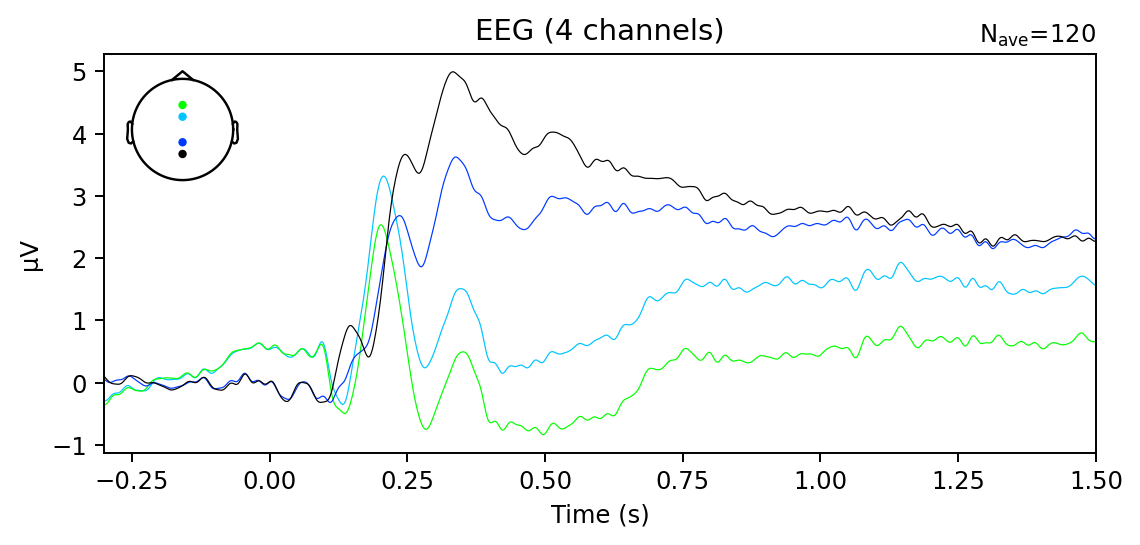

In [4]:
%matplotlib qt 
gr.plot(picks=['FCz','Fz','CPz','Pz'])

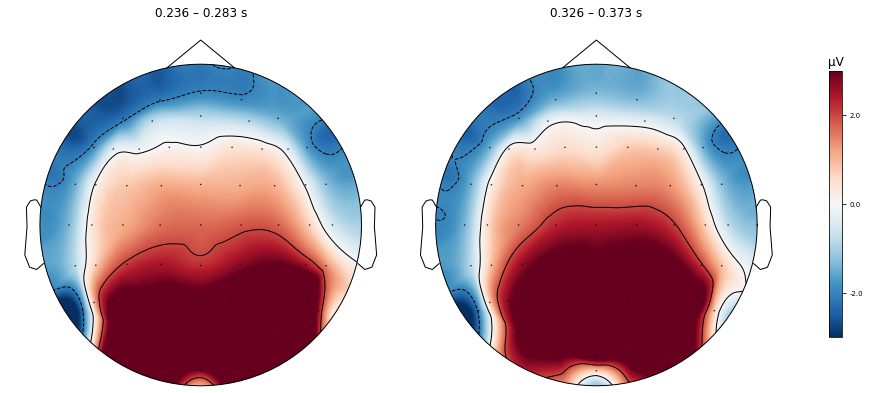

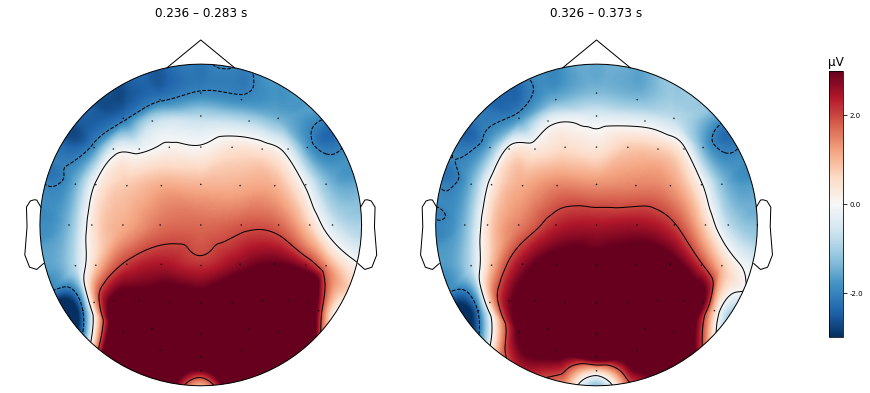

In [8]:
%matplotlib inline
gr.plot_topomap(
    ch_type='eeg', 
    times=[0.260,.35], 
    average=0.05, 
    vlim=(-3, 3),
    contours=2,
    res=256,
    border=0,
    size=4,
    image_interp='cubic',
)

In [9]:
evokeds_ERP_motiv_amotiv = {'motiv': np.concatenate([evokeds_TD_all[cond] for cond in ['motiv/extr', 'motiv/hard', 'motiv/easy']]).tolist(),
                          'amotiv': np.concatenate([evokeds_TD_all[cond] for cond in ['amotiv/extr', 'amotiv/hard', 'amotiv/easy']]).tolist()}
contrast_motiv = mne.combine_evoked([mne.grand_average([x for x in evokeds_ERP_motiv_amotiv['motiv']]), mne.grand_average([x for x in evokeds_ERP_motiv_amotiv['amotiv']])], weights=[1, -1])


Identifying common channels ...
Identifying common channels ...


combining channels using "mean"
combining channels using "mean"


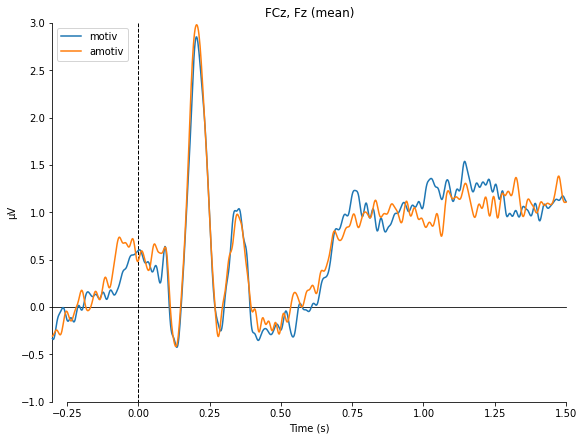

[<Figure size 576x432 with 1 Axes>]

In [10]:
%matplotlib inline 
mne.viz.plot_compare_evokeds(evokeds_ERP_motiv_amotiv, picks=['FCz','Fz'], ylim=dict(eeg=[-1,3]), ci=False, combine='mean')

combining channels using "mean"
combining channels using "mean"


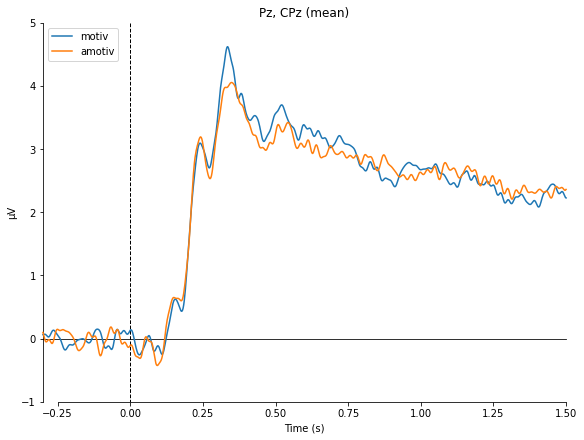

[<Figure size 576x432 with 1 Axes>]

In [13]:
mne.viz.plot_compare_evokeds(evokeds_ERP_motiv_amotiv, picks=['Pz','CPz'], ci=False, ylim=dict(eeg=[-1,5]),combine='mean')

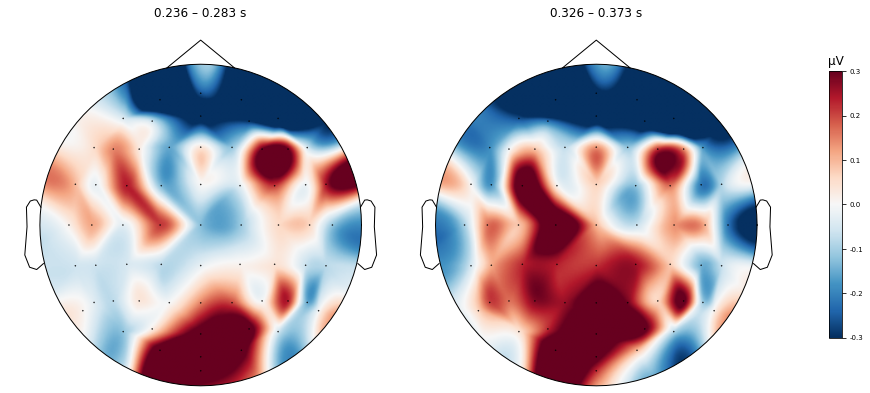

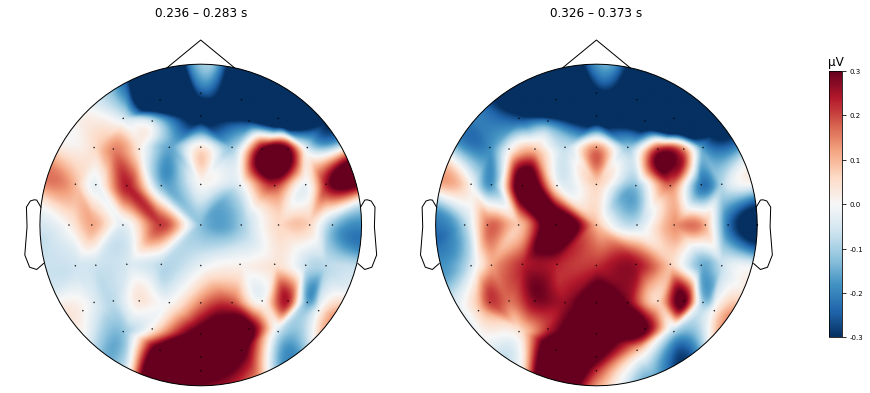

In [14]:
contrast_motiv.plot_topomap(
    ch_type='eeg', 
    times=[0.26, .35], 
    average=0.05, 
    vlim=(-.3, .3),
    contours=0,
    res=256,
    border=0,
    size=4,
    image_interp='cubic')

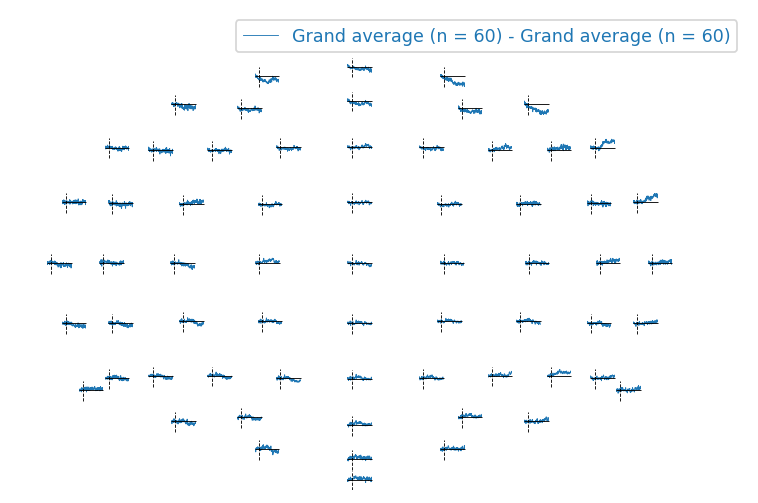

In [15]:
%matplotlib qt
contrast_motiv.plot_topo()

In [16]:
evokeds_ERP_easy_hard = {'easy': np.concatenate([evokeds_TD_all[cond] for cond in ['amotiv/easy', 'motiv/easy']]).tolist(),
                          'hard': np.concatenate([evokeds_TD_all[cond] for cond in ['amotiv/hard', 'motiv/hard']]).tolist()}
contrast_difficulty = mne.combine_evoked([mne.grand_average([x for x in evokeds_ERP_easy_hard['hard']]), mne.grand_average([x for x in evokeds_ERP_easy_hard['easy']])], weights=[1, -1])

Identifying common channels ...
Identifying common channels ...


combining channels using "mean"
combining channels using "mean"


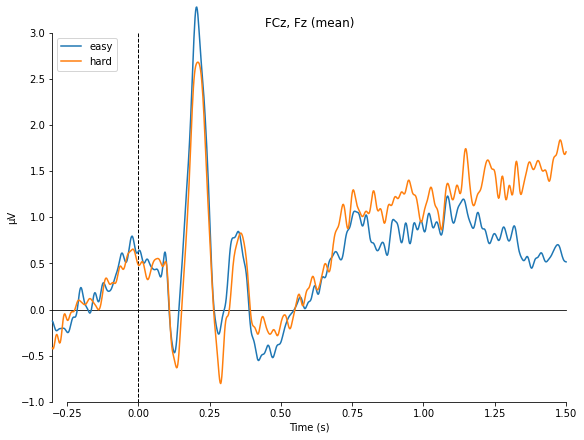

[<Figure size 576x432 with 1 Axes>]

In [17]:
%matplotlib inline
mne.viz.plot_compare_evokeds(evokeds_ERP_easy_hard, picks=['FCz','Fz'], ylim=dict(eeg=[-1,3]), ci=False, combine='mean')

combining channels using "mean"
combining channels using "mean"


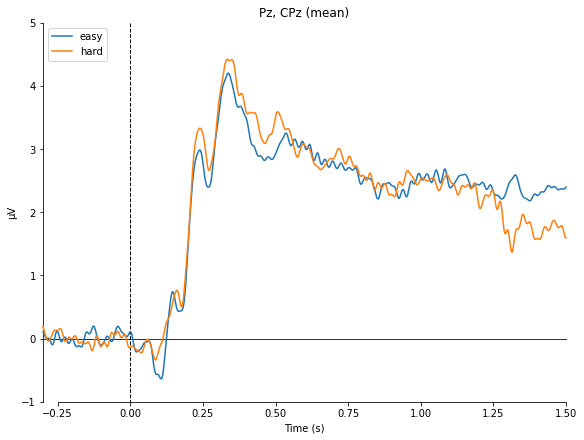

[<Figure size 576x432 with 1 Axes>]

In [17]:
%matplotlib inline
mne.viz.plot_compare_evokeds(evokeds_ERP_easy_hard, picks=['Pz','CPz'], ylim=dict(eeg=[-1,5]), ci=False, combine='mean')

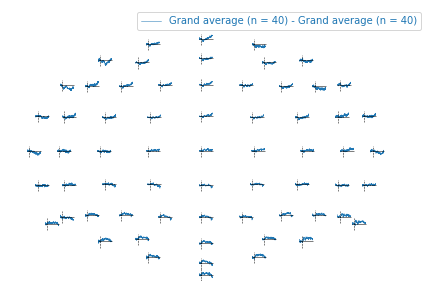

In [57]:
%matplotlib qt
contrast_difficulty.plot_topo()

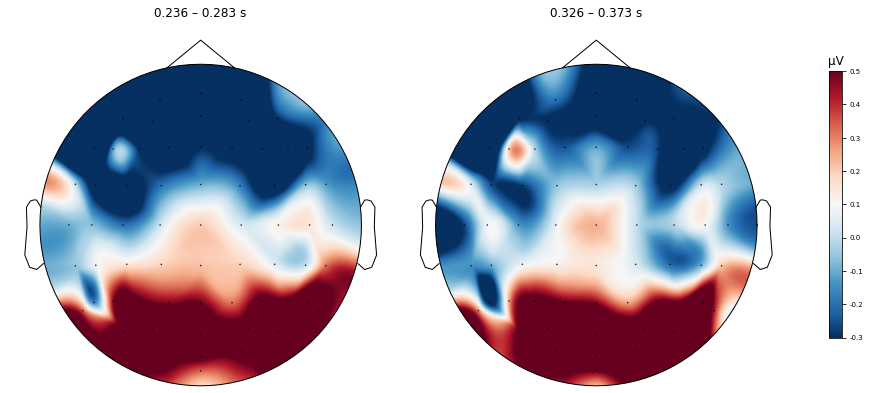

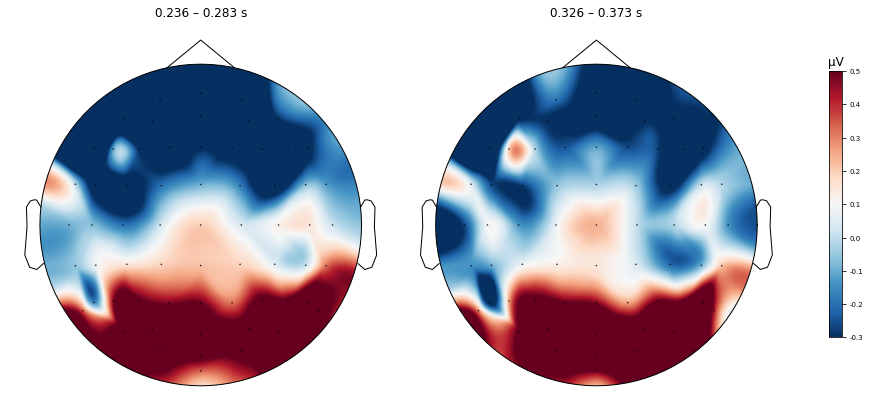

In [23]:
%matplotlib inline
contrast_difficulty.plot_topomap(
    ch_type='eeg', 
    times=[.26,.35], 
    average=0.05, 
    vlim=(-.3, .5),
    contours=0,
    res=256,
    border=0,
    size=4,
    image_interp='cubic')

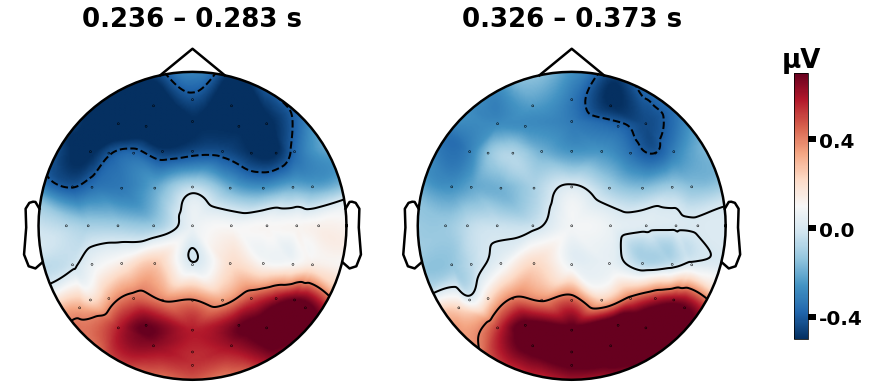

In [ ]:
%matplotlib inline
from scipy.ndimage import gaussian_filter
import numpy as np

# Get the data and smooth it spatially
evoked_smooth = contrast_difficulty.copy()

# Apply spatial smoothing across channels
data = evoked_smooth.get_data()
# Smooth across the channel dimension (axis 0)
for time_idx in range(data.shape[1]):
    data[:, time_idx] = gaussian_filter(data[:, time_idx], sigma=1)
evoked_smooth._data = data


vmin, vmax = -.5, .7

fig = evoked_smooth.plot_topomap(
    ch_type='eeg', 
    times=[0.26, .35], 
    average=0.05, 
    contours=2,
    res=256,
    border=0,
    size=4,
    vlim=(vmin, vmax),
    image_interp='cubic',
    show=False  # Don't show yet so we can modify
)

# Make everything bigger
for ax in fig.axes:
    # Make contour lines thicker
    for collection in ax.collections:
        collection.set_linewidth(2)  # Thicker contour lines
    
    for line in ax.lines:
        line.set_linewidth(2.5)  # Thicker head contour
        line.set_color('black')  # Make sure it's visible
    # Make axis labels bigger
    ax.title.set_fontsize(26)
    ax.title.set_fontweight('bold')
    

# Modify colorbar
cbar = fig.axes[-1]  # Colorbar is usually the last axis
cbar.tick_params(labelsize=20, width=6, length=8)  # Bigger ticks
for label in cbar.get_yticklabels():
    label.set_fontweight('bold')

# Make colorbar label bigger if present
if hasattr(cbar, 'yaxis'):
    cbar.yaxis.label.set_fontsize(14)
    cbar.yaxis.label.set_fontweight('bold')

plt.show()
# fig.savefig('topomap.png', dpi=300)